# 04 - SARIMA training for ds003029

Muc tieu:
1. Build multirun window features.
2. Train SARIMA thuan theo tung run.
3. Danh gia bang chronological train/test split.
4. Giu bo plot diagnostic cu va them bo plot tong hop 3 panel.

In [50]:
from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "ds003029_eda").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing src/ds003029_eda")


repo_root = find_repo_root()
sys.path.insert(0, str(repo_root / "src"))
repo_root

WindowsPath('C:/Users/admin/OneDrive - National Economics University/Documents/TÀI LIỆU/GIÁO TRÌNH HỌC/TIME SERIES/Seizure-Dectection-using-ECoG-')

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

from ds003029_eda.paths import get_paths
from ds003029_eda.sarima_training import run_sarima_training
from ds003029_eda.window_features_multirun import WindowingConfig, build_multirun_window_features

sns.set_style("whitegrid")

In [52]:
paths = get_paths(repo_root)
paths

WorkspacePaths(workspace=WindowsPath('C:/Users/admin/OneDrive - National Economics University/Documents/TÀI LIỆU/GIÁO TRÌNH HỌC/TIME SERIES/Seizure-Dectection-using-ECoG-'), dataset_root=WindowsPath('C:/Users/admin/OneDrive - National Economics University/Documents/TÀI LIỆU/GIÁO TRÌNH HỌC/TIME SERIES/Seizure-Dectection-using-ECoG-/EEG/ds003029'), outputs_dir=WindowsPath('C:/Users/admin/OneDrive - National Economics University/Documents/TÀI LIỆU/GIÁO TRÌNH HỌC/TIME SERIES/Seizure-Dectection-using-ECoG-/eda_outputs'))

In [53]:
features_df, info_df = build_multirun_window_features(
    paths=paths,
    config=WindowingConfig(window_sec=2.0, step_sec=1.0, max_channels=16),
    output_name="ds003029_window_features_multirun_full.csv",
    output_info_name="ds003029_windowing_multirun_full_info.csv",
)

display(features_df.head())
display(info_df.head())

Reading 0 ... 142199  =      0.000 ...   142.199 secs...


Reading 0 ... 338174  =      0.000 ...   338.174 secs...
Reading 0 ... 142199  =      0.000 ...   142.199 secs...
Reading 0 ... 152999  =      0.000 ...   152.999 secs...


,base,t_mid_s,rms,ptp,line_length,y
0,C:\Users\admin\OneDrive - National Economics U...,0.9995,0.000149,0.003321,0.005062,0
1,C:\Users\admin\OneDrive - National Economics U...,1.9995,0.000142,0.001356,0.004637,0
2,C:\Users\admin\OneDrive - National Economics U...,2.9995,0.000129,0.001525,0.004841,0
3,C:\Users\admin\OneDrive - National Economics U...,3.9995,0.000131,0.001775,0.005503,0
4,C:\Users\admin\OneDrive - National Economics U...,4.9995,0.000131,0.001775,0.005415,0


,base,sfreq,duration_s,window_sec,step_sec,n_channels_available,n_channels_used,n_windows,n_positive_windows
0,C:\Users\admin\OneDrive - National Economics U...,1000.0,142.199,2.0,1.0,135,16,141,21
1,C:\Users\admin\OneDrive - National Economics U...,1000.0,338.174,2.0,1.0,135,16,337,209
2,C:\Users\admin\OneDrive - National Economics U...,1000.0,142.199,2.0,1.0,135,16,141,21
3,C:\Users\admin\OneDrive - National Economics U...,1000.0,152.999,2.0,1.0,135,16,152,26


In [54]:
prepared, metrics_df = run_sarima_training(
    feature_path="ds003029_window_features_multirun_full.csv",
    output_subdir="sarima_training",
    paths=paths,
    min_total_obs=36,
    min_test_obs=12,
    test_fraction=0.2,
)

display(metrics_df)

,series_id,n_obs,n_train,n_test,cadence_s,target_col,ictal_window_rate,candidate_orders,candidate_seasonal_periods_steps,selected_order,...,mse_test,rmse_test,mae_test,median_ae_test,mape_test_pct,smape_test_pct,r2_test,ljungbox_pvalue_train_residual,status,notes
0,C:\Users\admin\OneDrive - National Economics U...,141,112,29,1.0,rms,0.148936,"[(1, 0, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (...","[4, 6, 12, 24]","(1, 0, 0)",...,1.381237e-09,0.000037,0.000030,0.000026,24.786240,22.619106,-0.159072,0.007022,ok,Pure SARIMA with chronological train/test spli...
1,C:\Users\admin\OneDrive - National Economics U...,337,269,68,1.0,rms,0.620178,"[(1, 0, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (...","[4, 6, 12, 24]","(1, 0, 0)",...,1.750611e-09,0.000042,0.000039,0.000041,42.918715,33.844853,-3.545257,0.000009,ok,Pure SARIMA with chronological train/test spli...
2,C:\Users\admin\OneDrive - National Economics U...,141,112,29,1.0,rms,0.148936,"[(1, 0, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (...","[4, 6, 12, 24]","(1, 0, 0)",...,2.281212e-09,0.000048,0.000046,0.000045,36.443638,30.179234,-10.903171,0.000230,ok,Pure SARIMA with chronological train/test spli...
3,C:\Users\admin\OneDrive - National Economics U...,152,121,31,1.0,rms,0.171053,"[(1, 0, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (...","[4, 6, 12, 24]","(1, 0, 0)",...,1.680094e-09,0.000041,0.000035,0.000030,24.608437,21.214339,-0.826221,0.000015,ok,Pure SARIMA with chronological train/test spli...


In [55]:
ok_metrics = metrics_df[metrics_df["status"] == "ok"].copy()
display(
    ok_metrics[
        [
            "series_id",
            "n_train",
            "n_test",
            "selected_order",
            "selected_seasonal_order",
            "aic_train",
            "rmse_test",
            "mae_test",
            "mape_test_pct",
            "r2_test",
            "ljungbox_pvalue_train_residual",
        ]
    ]
)

,series_id,n_train,n_test,selected_order,selected_seasonal_order,aic_train,rmse_test,mae_test,mape_test_pct,r2_test,ljungbox_pvalue_train_residual
0,C:\Users\admin\OneDrive - National Economics U...,112,29,"(1, 0, 0)","(0, 0, 0, 0)",-2148.071475,0.000037,0.000030,24.786240,-0.159072,0.007022
1,C:\Users\admin\OneDrive - National Economics U...,269,68,"(1, 0, 0)","(0, 0, 0, 0)",-5083.687212,0.000042,0.000039,42.918715,-3.545257,0.000009
2,C:\Users\admin\OneDrive - National Economics U...,112,29,"(1, 0, 0)","(0, 0, 0, 0)",-1963.999438,0.000048,0.000046,36.443638,-10.903171,0.000230
3,C:\Users\admin\OneDrive - National Economics U...,121,31,"(1, 0, 0)","(0, 0, 0, 0)",-2153.432666,0.000041,0.000035,24.608437,-0.826221,0.000015


In [56]:
predictions_path = paths.outputs_dir / "sarima_training" / "sarima_all_predictions.csv"
predictions_df = pd.read_csv(predictions_path)
display(predictions_df.head())

,series_id,t_mid_s,rms,split,sarima_pred,sarima_residual,y
0,C:\Users\admin\OneDrive - National Economics U...,0.9995,0.000149,train,0.000137,1.132544e-05,0
1,C:\Users\admin\OneDrive - National Economics U...,1.9995,0.000142,train,0.000147,-4.340972e-06,0
2,C:\Users\admin\OneDrive - National Economics U...,2.9995,0.000129,train,0.000141,-1.227244e-05,0
3,C:\Users\admin\OneDrive - National Economics U...,3.9995,0.000131,train,0.000131,1.649606e-07,0
4,C:\Users\admin\OneDrive - National Economics U...,4.9995,0.000131,train,0.000132,-1.453305e-06,0


In [57]:
selected_series_id = ok_metrics.iloc[0]["series_id"]
series_df = predictions_df[predictions_df["series_id"] == selected_series_id].copy()
series_df = series_df.sort_values("t_mid_s").reset_index(drop=True)
train_mask = series_df["split"] == "train"
test_mask = series_df["split"] == "test"
series_df["abs_error"] = (series_df["rms"] - series_df["sarima_pred"]).abs()
split_time = series_df.loc[test_mask, "t_mid_s"].min()
selected_series_id

'C:\\Users\\admin\\OneDrive - National Economics University\\Documents\\TÀI LIỆU\\GIÁO TRÌNH HỌC\\TIME SERIES\\Seizure-Dectection-using-ECoG-\\EEG\\ds003029\\sub-jh101\\ses-presurgery\\ieeg\\sub-jh101_ses-presurgery_task-ictal_acq-ecog_run-01_ieeg'

In [58]:
def add_ictal_spans(ax, df, color="orange", alpha=0.12):
    if "y" not in df.columns:
        return
    ictal = df[["t_mid_s", "y"]].copy()
    ictal["y"] = ictal["y"].fillna(0).astype(int)
    active = ictal[ictal["y"] == 1].copy()
    if active.empty:
        return
    groups = (active.index.to_series().diff().fillna(1) != 1).cumsum()
    for _, block in active.groupby(groups):
        start_t = block["t_mid_s"].min()
        end_t = block["t_mid_s"].max()
        ax.axvspan(start_t, end_t, color=color, alpha=alpha)

## Diagnostic plots (giu bo plot cu)

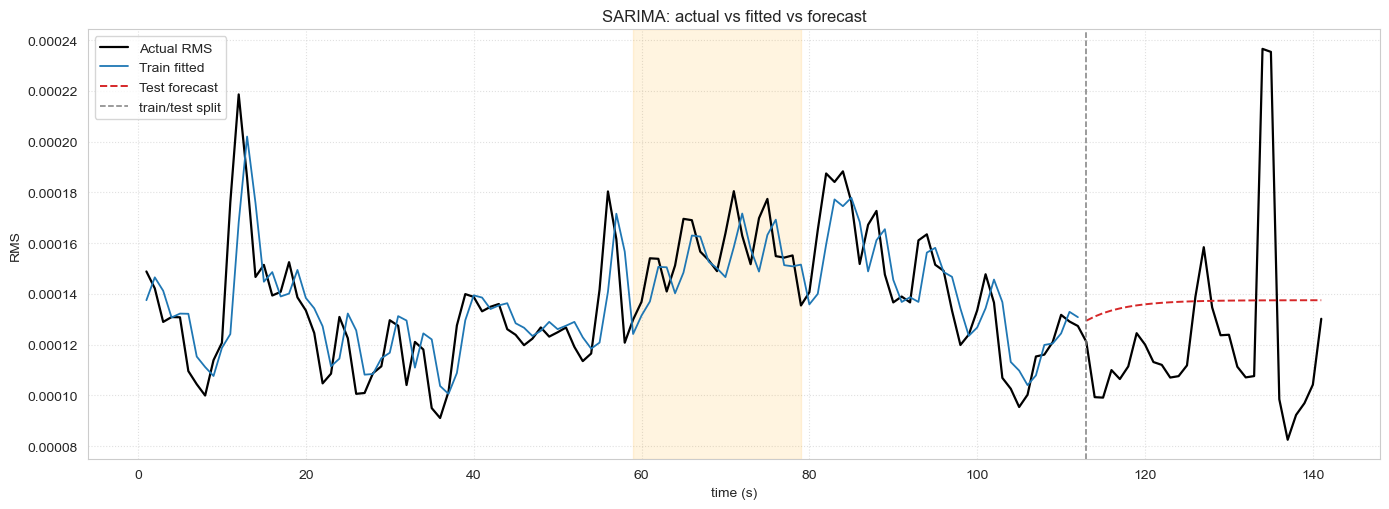

In [59]:
fig, ax = plt.subplots(figsize=(14, 5.2))
ax.plot(series_df["t_mid_s"], series_df["rms"], label="Actual RMS", color="black", linewidth=1.6)
ax.plot(series_df.loc[train_mask, "t_mid_s"], series_df.loc[train_mask, "sarima_pred"], label="Train fitted", color="tab:blue", linewidth=1.3)
ax.plot(series_df.loc[test_mask, "t_mid_s"], series_df.loc[test_mask, "sarima_pred"], label="Test forecast", color="tab:red", linewidth=1.4, linestyle="--")
ax.axvline(split_time, color="gray", linestyle="--", linewidth=1.1, label="train/test split")
add_ictal_spans(ax, series_df)
ax.set_title("SARIMA: actual vs fitted vs forecast")
ax.set_xlabel("time (s)")
ax.set_ylabel("RMS")
ax.legend(loc="best")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

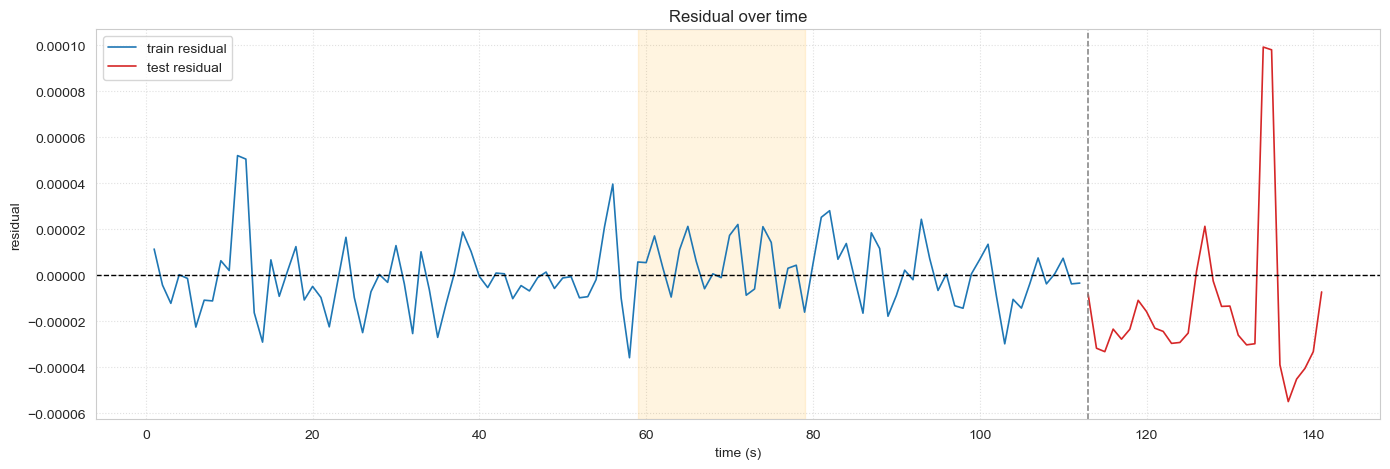

In [60]:
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(series_df.loc[train_mask, "t_mid_s"], series_df.loc[train_mask, "sarima_residual"], color="tab:blue", linewidth=1.2, label="train residual")
ax.plot(series_df.loc[test_mask, "t_mid_s"], series_df.loc[test_mask, "sarima_residual"], color="tab:red", linewidth=1.2, label="test residual")
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.axvline(split_time, color="gray", linestyle="--", linewidth=1.1)
add_ictal_spans(ax, series_df)
ax.set_title("Residual over time")
ax.set_xlabel("time (s)")
ax.set_ylabel("residual")
ax.legend(loc="best")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

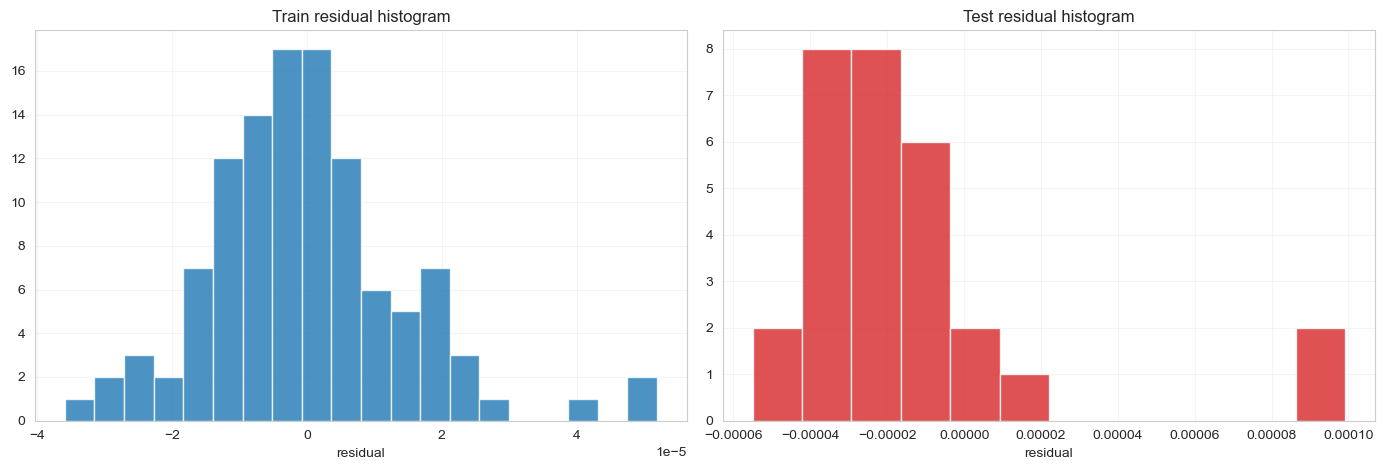

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].hist(series_df.loc[train_mask, "sarima_residual"].dropna(), bins=20, color="tab:blue", alpha=0.8)
axes[0].set_title("Train residual histogram")
axes[0].set_xlabel("residual")
axes[0].grid(alpha=0.2)
axes[1].hist(series_df.loc[test_mask, "sarima_residual"].dropna(), bins=12, color="tab:red", alpha=0.8)
axes[1].set_title("Test residual histogram")
axes[1].set_xlabel("residual")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

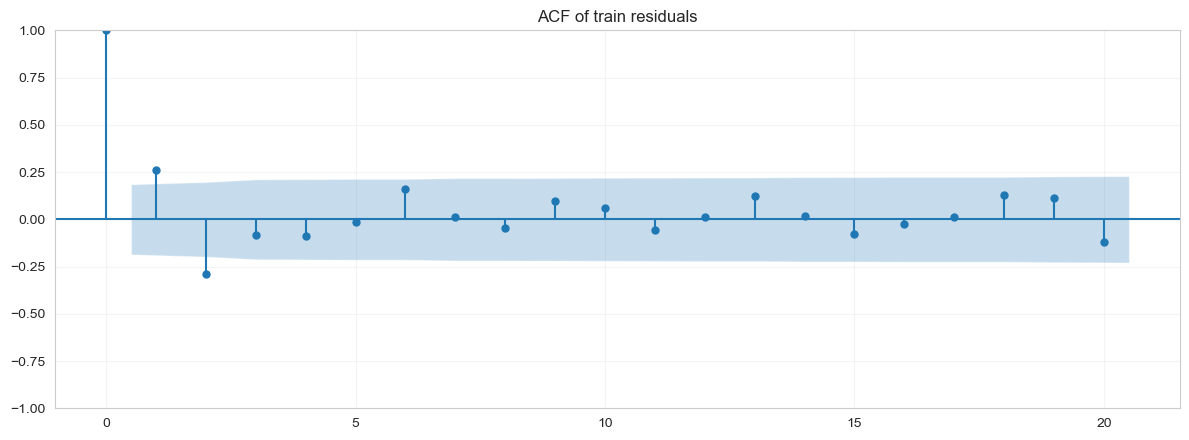

In [62]:
fig, ax = plt.subplots(figsize=(12, 4.5))
plot_acf(series_df.loc[train_mask, "sarima_residual"].dropna(), ax=ax, lags=min(20, int(train_mask.sum()) - 1))
ax.set_title("ACF of train residuals")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Summary report plot (them bo plot 3 panel moi)

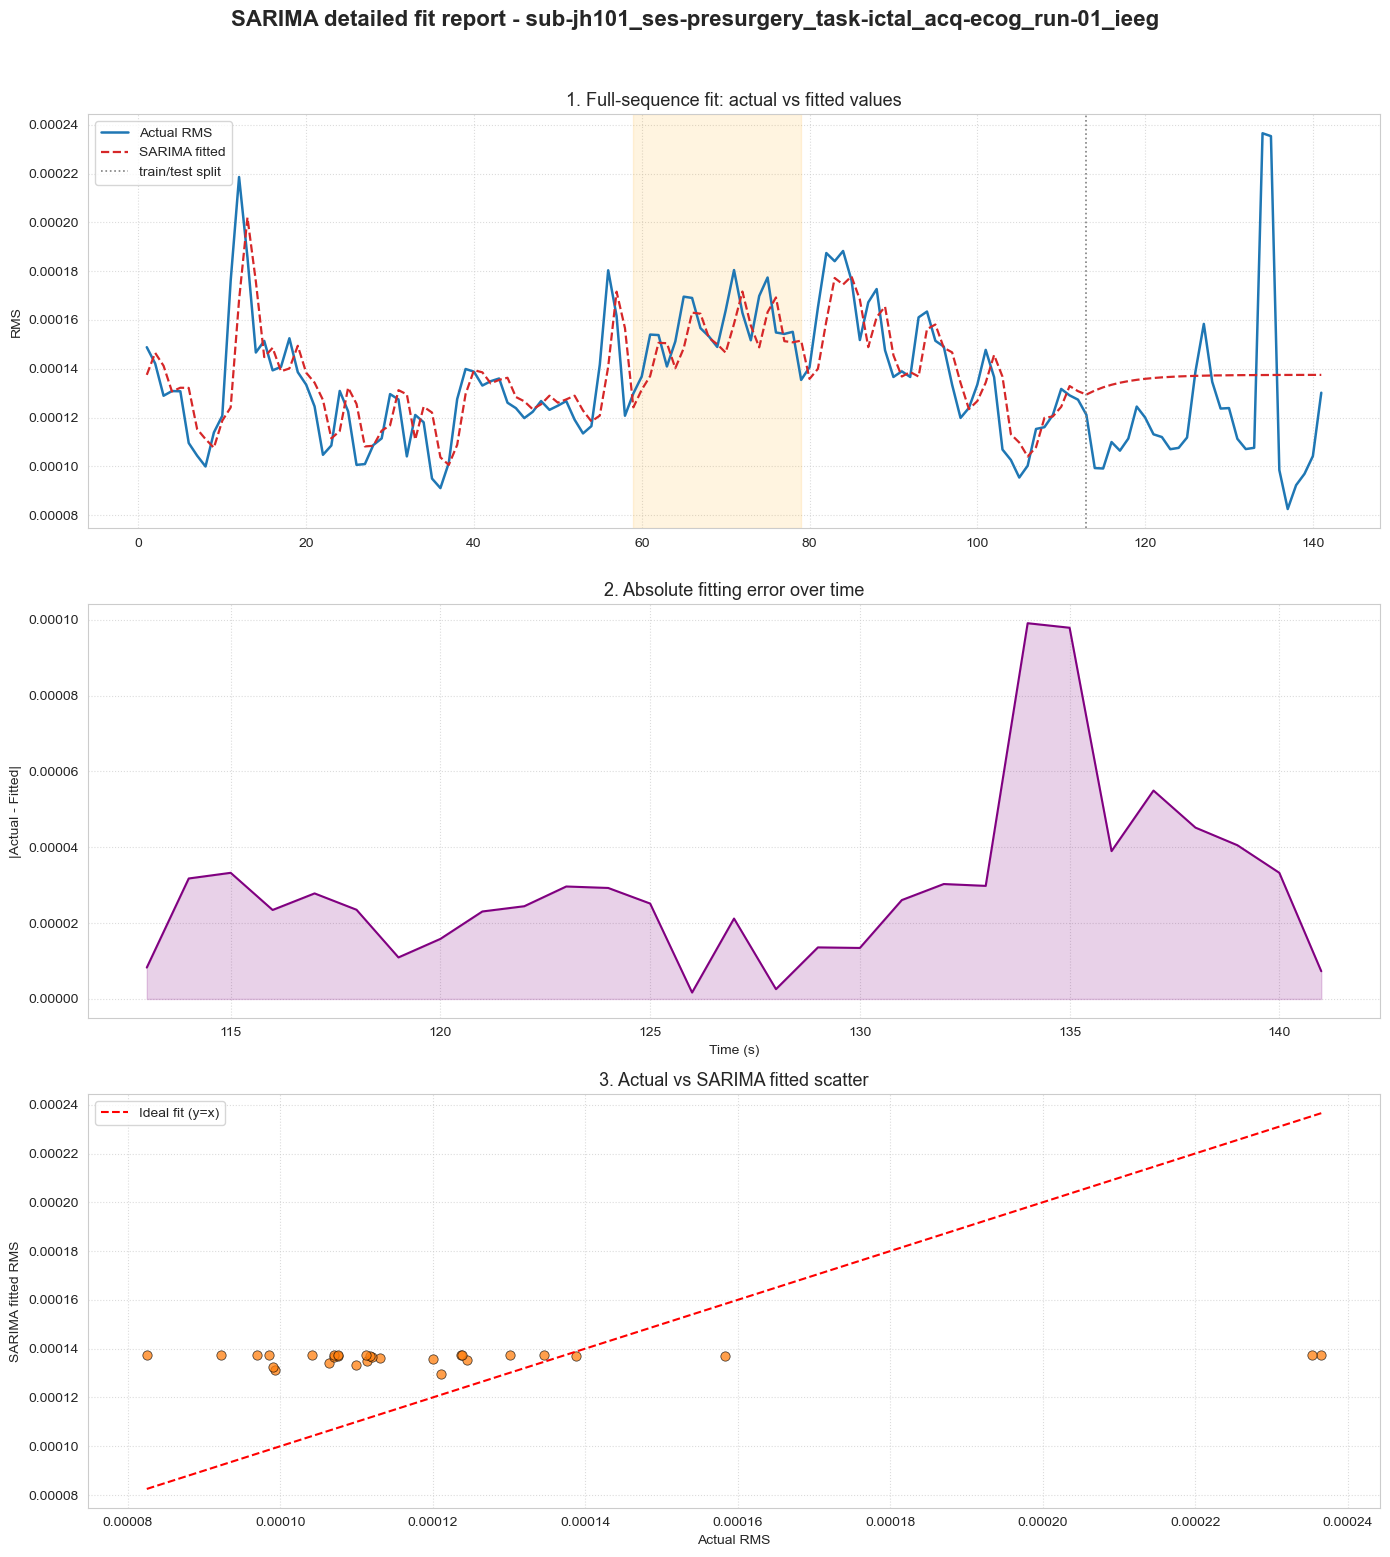

In [63]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle(
    f"SARIMA detailed fit report - {Path(str(selected_series_id)).stem}",
    fontsize=16,
    fontweight="bold",
    y=0.97,
)

axes[0].plot(series_df["t_mid_s"], series_df["rms"], label="Actual RMS", color="#1f77b4", linewidth=1.8)
axes[0].plot(series_df["t_mid_s"], series_df["sarima_pred"], label="SARIMA fitted", color="#d62728", linestyle="--", linewidth=1.6)
axes[0].axvline(split_time, color="gray", linestyle=":", linewidth=1.2, label="train/test split")
add_ictal_spans(axes[0], series_df)
axes[0].set_title("1. Full-sequence fit: actual vs fitted values", fontsize=13)
axes[0].set_ylabel("RMS")
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle=":", alpha=0.7)

test_plot = series_df.loc[test_mask, ["t_mid_s", "abs_error"]].copy()
axes[1].plot(test_plot["t_mid_s"], test_plot["abs_error"], color="purple", linewidth=1.5)
axes[1].fill_between(test_plot["t_mid_s"], test_plot["abs_error"], color="purple", alpha=0.18)
axes[1].set_title("2. Absolute fitting error over time", fontsize=13)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("|Actual - Fitted|")
axes[1].grid(True, linestyle=":", alpha=0.7)

scatter_df = series_df.loc[test_mask, ["rms", "sarima_pred"]].copy()
sns.scatterplot(
    data=scatter_df,
    x="rms",
    y="sarima_pred",
    ax=axes[2],
    color="#ff7f0e",
    edgecolor="k",
    alpha=0.75,
    s=45,
)
min_val = min(scatter_df["rms"].min(), scatter_df["sarima_pred"].min())
max_val = max(scatter_df["rms"].max(), scatter_df["sarima_pred"].max())
axes[2].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1.5, label="Ideal fit (y=x)")
axes[2].set_title("3. Actual vs SARIMA fitted scatter", fontsize=13)
axes[2].set_xlabel("Actual RMS")
axes[2].set_ylabel("SARIMA fitted RMS")
axes[2].legend(loc="upper left")
axes[2].grid(True, linestyle=":", alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()